## Test 02 - Half wing load test (Failed test)

This load test's intention was to prove the construction of the wing as defined in [`definitions/mk2/`](../../definitions/mk2/).

<p align="center">
  <img src="../../definitions/mk2/planform.png" alt="mk2 planform" width="70%">
</p>

<p align="center">
  <img src="../../imagenes/cantilever_wing.jpg" alt="mk2 half wing clamped as a cantilever, loaded with plates" width="60%">
  <br>
  <sub><i>mk2 half wing clamped at its root plate as a cantilever, plates spread along the span</i></sub>
</p>

The intended load for this wing on the uniform load mode, was to reach at least 3x the wing load factor which was originaly thought and designed
for this wing, a very ambitious 100 kg/m2 loading.

Sadly this build did not go as planned for a few reasons:
- The attachment plate at the wing root was badly designed, and wasn't enough material nor thickness to transfer all the load. Even more so, the transition
from one wall at the root, to many walls on the initial layers of the plate and wing root foot probably created a large stress concentration on the skin.
- Most importantly, the sleeve joint did not work as expected this time. The "household" epoxy branch chosen in this build did not even cure entirely and so
there was delamination at the sleeve very early on.
- The density and infill of choice near the rod tubes was also badly chosen, a different path to that of the ellipse was taken, more ambitious as well
removing weight, but the entire extra-density tube was delaminated along with the rods and the rods did not fail this time.

<p align="center">
  <img src="../../imagenes/failed_wrinkle_skin.jpg" alt="Skin wrinkled and cracked at the root plate" width="40%">
  <br>
  <sub><i>The failure: the skin wrinkled and cracked right where it meets the root plate</i></sub>
</p>

## What the test was going to put on it

The test failed before it got to the load it was built for, so this notebook works out what the wing *would* have seen, and
what the models say about it. Same two models as the rest of the repo: rods only
([`analysis/idealized_rods_only.ipynb`](../../analysis/idealized_rods_only.ipynb)) and the
transformed section ([`experiment-01`](../experiment-01/ellipse_test.ipynb),
[`experiment-03`](../experiment-03/mk2_joint_test.ipynb)), now on the whole panel as a cantilever.

**The design case.** mk2 is 1600 mm of span at an average chord of 180 mm, so $S = 0.288$ m². At
100 kg/m² that is a **28.8 kg aircraft**. The panel on the bench is one half wing, so it carries
**half** of it: $L = n\,m\,g/2$, spread uniformly along the 800 mm.

| load factor | whole aircraft | **on this half wing** | $w$ |
|---|---|---|---|
| 1 g | 28.8 kg | **14.4 kg** | 0.18 N/mm |
| 3 g | 86.4 kg | **43.2 kg** | 0.53 N/mm |
| 5 g | 144.0 kg | **72.0 kg** | 0.88 N/mm |
| 7 g | 201.6 kg | **100.8 kg** | 1.24 N/mm |

.

| | as built |
|---|---|
| article | the whole mk2 panel, sections 00-03, z = 0-800 mm, NACA 4412, chord 200 → 160 mm |
| rods | 5 / 3 / 1 / 1 pairs of 3 mm carbon. Laps at z 175-225, 375-425, 575-625 |
| printed joints | z = 200, 400, 600 mm, 15 mm glued sleeve |
| root | clamped through the 20 mm root plate (`add_root_plate.py`), rods seated through it |
| print | standing on end, 1 wall (0.42 mm), 5 % lattice, 10 % bell, same build as experiment-03 |
| load | uniform along the span, $n$ = 1, 3, 5, 7. Clamped upside down, plates on the lower surface, so the upper surface is in compression, as in flight |

In [1]:
from __future__ import annotations

import importlib.util
import math
import pathlib
import sys
from dataclasses import dataclass
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
})
ROD, MED, WARN = "#1b3a6b", "#c2703d", "#b3283c"
SHADES = ["#8fa9cf", ROD, MED, WARN]

G = 9.81          # m/s^2.  Lengths mm, forces N, stresses MPa throughout.

ROOT = next(p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
            if (p / "wing_assembler").is_dir())
sys.path.insert(0, str(ROOT))

from wing_assembler.naca import naca4_polygon_pts, offset_polygon
from wing_assembler.section_layout import _compute_physical_rod_sections, chord_at

spec = importlib.util.spec_from_file_location("_mk2", ROOT / "definitions/mk2/wing_definition_mk2.py")
_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_mod)
wing = _mod.wing


@dataclass
class Test:
    """The article and the load it was going to get."""
    mass_kg: float = 28.8          # whole aircraft, WL 100 on 0.288 m^2
    n_cases: tuple = (1.0, 3.0, 5.0, 7.0)
    rod_d: float = 3.0             # mm  in the definition's 3.5 mm bore
    wall_t: float = 0.42           # mm  one loop
    infill: float = 0.05
    bell_rho: float = 0.10
    plate_grip: float = 20.0       # mm  rod seated in the root plate
    joints: tuple = (200.0, 400.0, 600.0)

    @property
    def span(self): return wing.span
    @property
    def A_rod(self): return math.pi * self.rod_d ** 2 / 4

    def panel_kg(self, n):  return n * self.mass_kg / 2

    def pairs(self) -> list[dict]:
        return [dict(span=ps.r, x=r.abs_x, yu=r.abs_yu, yl=r.abs_yl,
                     z0=ps.z_bounds_start, z1=min(ps.z_bounds_end, r.z_cut_off))
                for ps in _compute_physical_rod_sections(wing) for r in ps.rods]

    def laps(self) -> list[tuple[float, float]]:
        spans = sorted({(p["span"], p["z0"], p["z1"]) for p in self.pairs()})
        return [(b[1], a[2]) for a, b in zip(spans, spans[1:])]

    def pairs_at(self, z: float) -> list[dict]:
        return [p for p in self.pairs() if p["z0"] <= z <= p["z1"]]

    def loads(self, z, n: float = 1.0):
        """(w, V, M) of a uniform load on a cantilever clamped at z = 0. Lift-up positive."""
        w = self.panel_kg(n) * G / self.span
        return np.full_like(z, w), w * (self.span - z), w * (self.span - z) ** 2 / 2


t = Test()
PAIRS = t.pairs()
LAPS = t.laps()


## Section and bending

The transformed section from experiment-03, unchanged. At every millimetre of span:

1. **Stiffness of the section.** Add up how much each material resists bending: the skin, the
   infill (knocked down to almost nothing at 5 %), and whichever rods are in the section at that
   station. Carbon is ~60 times stiffer than the plastic, so the rods dominate.
2. **Load at that station.** On a cantilever with a uniform load, the bending moment grows with the
   square of the distance to the tip, so it is highest at the root.
3. **Stress.** Moment divided by stiffness gives how much the section bends there. Multiply that by
   each material's stiffness and its distance from the neutral axis, and you get the stress in the
   rods and in the skin.
4. **Deflection.** Add up the bending from the root out to the tip.
5. **Shear into the plastic.** How much load each rod has to pick up from the plastic around it,
   per mm of rod. This is what the bell and infill have to carry.

Three cases for how much the plastic counts:

| case | what it assumes |
|---|---|
| **A** rods only | plastic $E = 0$, the boom idealization |
| **B** $E$ = 2000 | printed PLA across layers, the working number |
| **C** $E$ = 3500 | bulk PLA, the optimistic end |

Signs are for **lift**: upper skin and upper rods in compression. That is also how the bench
loaded it: the wing was clamped **upside down**, with the plates pressing on the lower surface,
which faced up. So the upper skin and upper rods were in compression, as in flight.

The model is linear, so it is solved once at 1 g and scaled.

In [2]:
@dataclass
class Mat:
    E: float = 2_000.0          # MPa  printed wall, along the span
    infill: float = t.infill
    E_rod: float = 125_000.0    # MPa  pultruded carbon
    nu: float = 0.35

    @property
    def E_in(self): return self.E * self.infill ** 2


def _poly(pts):
    """(A, int y dA, int y^2 dA) of a closed polygon."""
    x = np.asarray([p[0] for p in pts] + [pts[0][0]])
    y = np.asarray([p[1] for p in pts] + [pts[0][1]])
    cr = x[:-1] * y[1:] - x[1:] * y[:-1]
    A, Q = cr.sum() / 2, (cr * (y[:-1] + y[1:])).sum() / 6
    I = (cr * (y[:-1] ** 2 + y[:-1] * y[1:] + y[1:] ** 2)).sum() / 12
    s = 1.0 if A >= 0 else -1.0
    return A * s, Q * s, I * s


def _disc(r, yc):
    A = math.pi * r * r
    return A, A * yc, A * (yc * yc + r * r / 4)


@lru_cache(maxsize=None)
def _shell(chord: float):
    outer = naca4_polygon_pts(wing.naca, chord)
    ys = [p[1] for p in outer]
    return _poly(outer), _poly(offset_polygon(outer, t.wall_t)), max(ys), min(ys)


def section(z: float, m: Mat) -> dict:
    so, si, y_top, y_bot = _shell(round(chord_at(z, wing) * 2) / 2)
    ps = t.pairs_at(z)
    terms = [("skin", m.E, *so), ("skin", -m.E, *si), ("infill", m.E_in, *si)]
    for p in ps:
        for y in (p["yu"], p["yl"]):
            terms.append(("infill", -m.E_in, *_disc(wing.rod_diameter / 2, y)))
            terms.append(("rods", m.E_rod, *_disc(t.rod_d / 2, y)))
    EA = sum(E * A for _, E, A, _, _ in terms)
    y_na = sum(E * Q for _, E, _, Q, _ in terms) / EA
    parts = {}
    for name, E, A, Q, I in terms:
        parts[name] = parts.get(name, 0.0) + E * (I - 2 * y_na * Q + y_na ** 2 * A)
    return dict(EI=sum(parts.values()), y_na=y_na, parts=parts, pairs=ps, y_top=y_top, y_bot=y_bot)


def _cum(f, x):
    """Cumulative trapezoid from x[0]."""
    return np.concatenate([[0.0], np.cumsum(np.diff(x) * (f[1:] + f[:-1]) / 2)])


def bend(m: Mat, dz: float = 0.5) -> dict:
    """The cantilever at 1 g. Multiply stresses, forces and deflection by n."""
    z = np.arange(0.0, t.span + dz / 2, dz)
    w, V, M = t.loads(z)
    keys = ("EI", "y_na", "rods_share", "rod_c", "rod_t", "skin_c", "skin_t", "q", "F_rod")
    r = {k: np.zeros_like(z) for k in keys}
    for i, zi in enumerate(z):
        s = section(float(zi), m)
        k, na = M[i] / s["EI"], s["y_na"]
        yu = [p["yu"] for p in s["pairs"]]
        yl = [p["yl"] for p in s["pairs"]]
        r["EI"][i], r["y_na"][i] = s["EI"], na
        r["rods_share"][i] = s["parts"]["rods"] / s["EI"]
        r["rod_c"][i] = m.E_rod * (max(yu) - na) * k
        r["rod_t"][i] = m.E_rod * (na - min(yl)) * k
        r["q"][i] = abs(V[i]) * m.E_rod * t.A_rod * max(abs(y - na) for y in yu + yl) / s["EI"]
        r["F_rod"][i] = r["rod_c"][i] * t.A_rod
        r["skin_c"][i] = m.E * (s["y_top"] - na) * k
        r["skin_t"][i] = m.E * (na - s["y_bot"]) * k
    theta = _cum(M / r["EI"], z)
    r.update(z=z, w=w, V=V, M=M, theta=theta, delta=_cum(theta, z))
    return r


CASES = {"A  rods only": Mat(E=0.0),
         "B  E = 2000":  Mat(),
         "C  E = 3500":  Mat(E=3_500.0)}
res = {name: bend(m) for name, m in CASES.items()}
rA, rB, rC = res["A  rods only"], res["B  E = 2000"], res["C  E = 3500"]
z = rB["z"]
in_lap = np.zeros_like(z, dtype=bool)
for a, b in LAPS:
    in_lap |= (z >= a) & (z <= b)

print(f"{'case':<14}{'EI root':>11}{'rods':>6}{'EI z=500':>11}{'rods':>6}{'EI z=700':>11}{'rods':>6}")
for name, r in res.items():
    row = f"{name:<14}"
    for zz in (0.0, 500.0, 700.0):
        i = int(np.searchsorted(z, zz))
        row += f"{r['EI'][i]:>11.3e}{100*r['rods_share'][i]:>5.0f}%"
    print(row)

case              EI root  rods   EI z=500  rods   EI z=700  rods
A  rods only    4.644e+08  100%  7.262e+07  100%  6.130e+07  100%
B  E = 2000     4.934e+08   94%  9.214e+07   79%  7.733e+07   79%
C  E = 3500     5.151e+08   90%  1.066e+08   68%  8.929e+07   69%


In [3]:
print(f"{'':<5}{'panel':>8}{'root M':>9}{'tip defl':>16}{'peak rod C':>20}{'':>9}"
      f"{'rod T':>7}{'crown C':>16}{'lower T':>9}")
print(f"{'':<5}{'kg':>8}{'N.m':>9}{'B   (A)':>16}{'B   (A)':>20}{'at z':>9}"
      f"{'B':>7}{'B, root':>16}{'B, root':>9}")
print("-" * 99)
iB, iA = int(np.argmax(rB["rod_c"])), int(np.argmax(rA["rod_c"]))
for n in t.n_cases:
    print(f"{n:>3.0f} g{t.panel_kg(n):>8.1f}{n*rB['M'][0]/1e3:>9.1f}"
          f"{n*rB['delta'][-1]:>9.1f} ({n*rA['delta'][-1]:>5.1f})"
          f"{n*rB['rod_c'][iB]:>12.1f} ({n*rA['rod_c'][iA]:>5.1f}){z[iB]:>8.0f} "
          f"{n*rB['rod_t'].max():>7.1f}{n*rB['skin_c'][0]:>16.2f}{n*rB['skin_t'][0]:>9.2f}")
print("\nmm and MPa.  Tip deflection is bending only, no shear term.  'crown C' and 'lower T' are the "
      "skin at the root,\nwhere the moment is highest and the root plate starts.")

        panel   root M        tip defl          peak rod C           rod T         crown C  lower T
           kg      N.m         B   (A)             B   (A)     at z      B         B, root  B, root
---------------------------------------------------------------------------------------------------
  1 g    14.4     56.5     24.3 ( 26.9)       114.1 (135.7)       0   118.9            2.94     2.91
  3 g    43.2    169.5     73.0 ( 80.7)       342.3 (407.1)       0   356.8            8.83     8.74
  5 g    72.0    282.5    121.7 (134.5)       570.6 (678.5)       0   594.7           14.72    14.57
  7 g   100.8    395.5    170.4 (188.3)       798.8 (949.9)       0   832.5           20.60    20.40

mm and MPa.  Tip deflection is bending only, no shear term.  'crown C' and 'lower T' are the skin at the root,
where the moment is highest and the root plate starts.


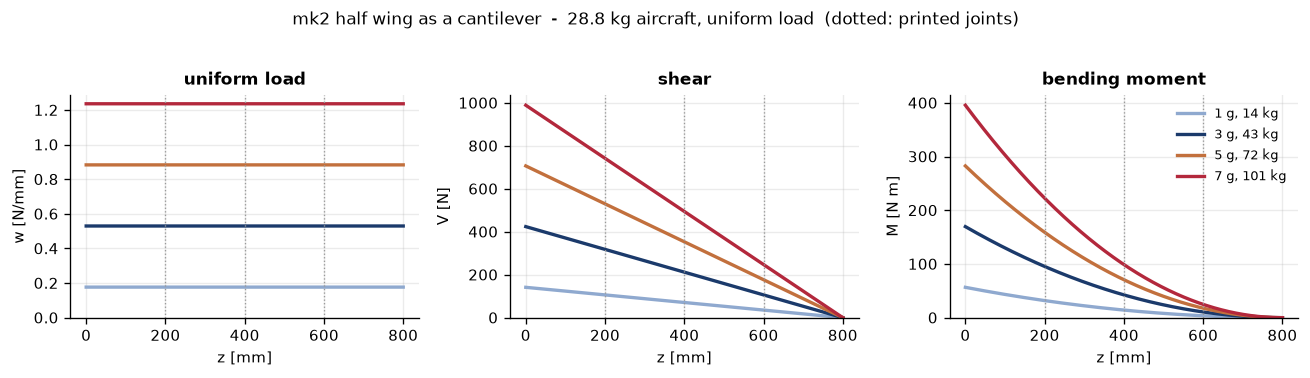

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.0))
for n, c in zip(t.n_cases, SHADES):
    lab = f"{n:.0f} g, {t.panel_kg(n):.0f} kg"
    ax[0].plot(z, n * rB["w"], color=c, lw=2, label=lab)
    ax[1].plot(z, n * rB["V"], color=c, lw=2, label=lab)
    ax[2].plot(z, n * rB["M"] / 1e3, color=c, lw=2, label=lab)
ax[0].set(xlabel="z [mm]", ylabel="w [N/mm]", title="uniform load", ylim=(0, None))
ax[1].set(xlabel="z [mm]", ylabel="V [N]", title="shear", ylim=(0, None))
ax[2].set(xlabel="z [mm]", ylabel="M [N m]", title="bending moment", ylim=(0, None))
for a in ax:
    for j in t.joints:
        a.axvline(j, color="#999", lw=0.8, ls=":")
ax[2].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle(f"mk2 half wing as a cantilever  -  {t.mass_kg:.1f} kg aircraft, uniform load"
             "  (dotted: printed joints)", fontsize=10, y=1.03)
fig.tight_layout(); plt.show()

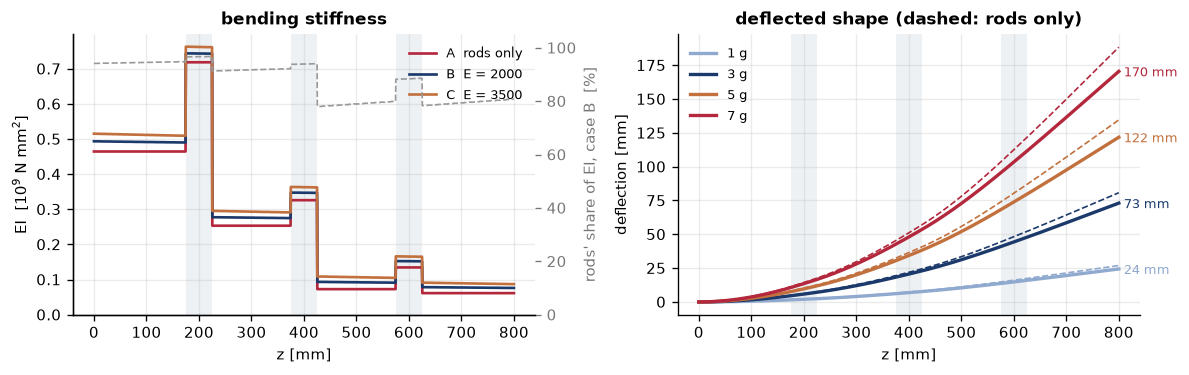

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

for (name, r), c in zip(res.items(), (WARN, ROD, MED)):
    ax[0].plot(z, r["EI"] / 1e9, color=c, lw=1.6, label=name)
ax[0].set(xlabel="z [mm]", ylabel="EI  [10$^9$ N mm$^2$]", title="bending stiffness", ylim=(0, None))
ax[0].legend(frameon=False, fontsize=8, loc="upper right")
axr = ax[0].twinx()
axr.plot(z, 100 * rB["rods_share"], color="#999", lw=1.0, ls="--")
axr.set_ylabel("rods' share of EI, case B  [%]", color="#777")
axr.set_ylim(0, 105); axr.grid(False); axr.tick_params(colors="#777")

for n, c in zip(t.n_cases, SHADES):
    ax[1].plot(z, n * rB["delta"], color=c, lw=2, label=f"{n:.0f} g")
    ax[1].plot(z, n * rA["delta"], color=c, lw=1, ls="--")
    ax[1].annotate(f"{n*rB['delta'][-1]:.0f} mm", (z[-1], n * rB["delta"][-1]), fontsize=8,
                   color=c, textcoords="offset points", xytext=(3, -3))
ax[1].set(xlabel="z [mm]", ylabel="deflection [mm]", title="deflected shape (dashed: rods only)")
ax[1].legend(frameon=False, fontsize=8, loc="upper left")

for a in ax:
    for lo, hi in LAPS:
        a.axvspan(lo, hi, color=ROD, alpha=0.07, lw=0)
fig.tight_layout(); plt.show()

## Stresses along the span

The same picture as `idealized_rods_only` §5, but with the plastic counted, and at the four load
factors. The shaded bands are the rod laps.

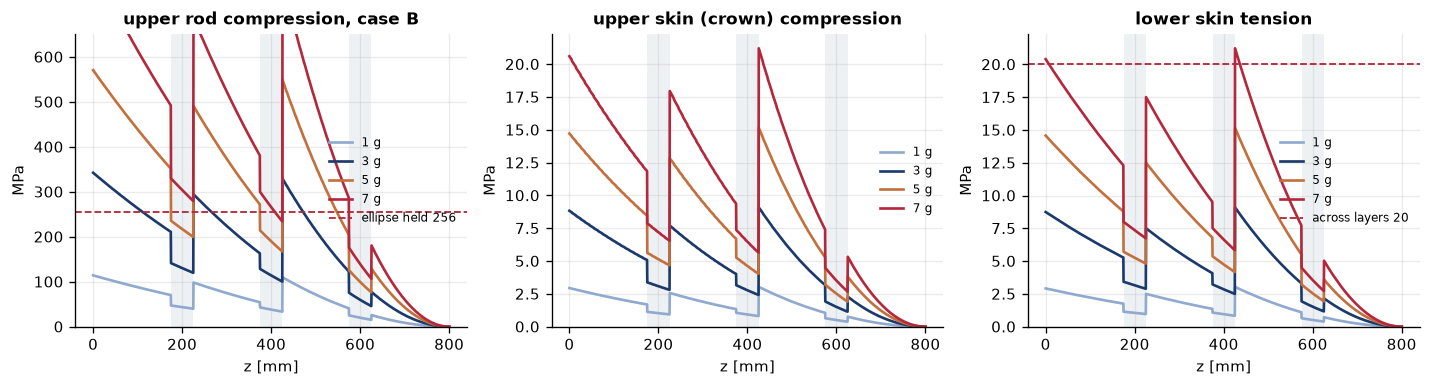

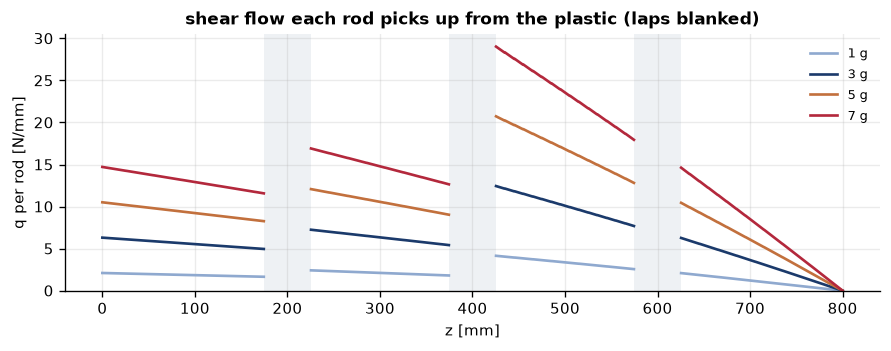

In [6]:
# experiment-01, the ellipse: peak rod stress while it held 80 kgf, per model case.
# The ellipse is symmetric about its neutral axis, so tension and compression were the same.
ELLIPSE_HELD = {"A  rods only": 282.3, "B  E = 2000": 255.8, "C  E = 3500": 239.0}   # MPa

fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
for n, c in zip(t.n_cases, SHADES):
    ax[0].plot(z, n * rB["rod_c"], color=c, lw=1.6, label=f"{n:.0f} g")
    ax[1].plot(z, n * rB["skin_c"], color=c, lw=1.6, label=f"{n:.0f} g")
    ax[2].plot(z, n * rB["skin_t"], color=c, lw=1.6, label=f"{n:.0f} g")
ax[0].axhline(ELLIPSE_HELD["B  E = 2000"], color=WARN, lw=1.1, ls="--",
              label=f"ellipse held {ELLIPSE_HELD['B  E = 2000']:.0f}")
ax[2].axhline(20.0, color=WARN, lw=1.1, ls="--", label="across layers 20")
ax[0].set(xlabel="z [mm]", ylabel="MPa", title="upper rod compression, case B", ylim=(0, 650))
ax[1].set(xlabel="z [mm]", ylabel="MPa", title="upper skin (crown) compression", ylim=(0, None))
ax[2].set(xlabel="z [mm]", ylabel="MPa", title="lower skin tension", ylim=(0, None))
for a in ax:
    for lo, hi in LAPS:
        a.axvspan(lo, hi, color=ROD, alpha=0.07, lw=0)
    a.legend(frameon=False, fontsize=7, loc="center right")
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.0))
for n, c in zip(t.n_cases, SHADES):
    ax.plot(z, np.where(in_lap, np.nan, n * rB["q"]), color=c, lw=1.6, label=f"{n:.0f} g")
for lo, hi in LAPS:
    ax.axvspan(lo, hi, color=ROD, alpha=0.07, lw=0)
ax.set(xlabel="z [mm]", ylabel="q per rod [N/mm]",
       title="shear flow each rod picks up from the plastic (laps blanked)", ylim=(0, None))
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

## Where it would have broken

Instead of guessing allowables for every part of the wing, start from what has actually been shown.

The ellipse tube in [`experiment-01`](../experiment-01/ellipse_test.ipynb) is the test that has put the most
stress into the rods so far. It held 80 kgf, and while it did, its worst rods were at **282 MPa**
on the rods-only model (**256 MPa** with the plastic counted, 239 MPa as bulk PLA). The ellipse is symmetric
about its neutral axis, so that is the stress in both the **tension** and the **compression** rods.
Nothing broke at that load, so these are not strengths, only stresses the rods are known to take.

**Should this wing, in all its span, have transferred the loads as the ellipse test did** (the rods
properly bonded, the plastic around them holding, the root and the joints passing the load
on), then the rods would have been fine at least up to the load that puts them at those same stresses.
That gives a floor. It is a very safe one, because the ellipse's rods did not break at those stresses.

Each model case is compared with the same case of the ellipse, so the choice of plastic stiffness
mostly cancels out.

In [7]:
print(f"{'case':<14}{'ellipse held':>13}{'wing, per g':>22}{'floor':>9}{'on panel':>11}{'at z':>7}")
print(f"{'':<14}{'MPa':>13}{'compr. / tension':>22}")
print("-" * 76)
floors = {}
for name, r in res.items():
    c_max, t_max = r["rod_c"].max(), r["rod_t"].max()
    worst = r["rod_t"] if t_max > c_max else r["rod_c"]
    g = ELLIPSE_HELD[name] / max(c_max, t_max)
    floors[name] = g
    print(f"{name:<14}{ELLIPSE_HELD[name]:>13.1f}{c_max:>12.1f} / {t_max:>6.1f}{g:>7.2f} g"
          f"{t.panel_kg(g):>8.1f} kg{z[np.argmax(worst)]:>7.0f}")

print("\nat the target load factors, case B asks the rods for:")
for n in t.n_cases:
    peak = n * max(rB["rod_c"].max(), rB["rod_t"].max())
    print(f"   {n:.0f} g  {t.panel_kg(n):6.1f} kg   {peak:6.1f} MPa   "
          f"{100*peak/ELLIPSE_HELD['B  E = 2000']:4.0f} % of what the ellipse held")


case           ellipse held           wing, per g    floor   on panel   at z
                        MPa      compr. / tension
----------------------------------------------------------------------------
A  rods only          282.3       135.7 /  135.7   2.08 g    30.0 kg    426
B  E = 2000           255.8       114.1 /  118.9   2.15 g    31.0 kg      0
C  E = 3500           239.0       109.9 /  113.3   2.11 g    30.4 kg      0

at the target load factors, case B asks the rods for:
   1 g    14.4 kg    118.9 MPa     46 % of what the ellipse held
   3 g    43.2 kg    356.8 MPa    139 % of what the ellipse held
   5 g    72.0 kg    594.7 MPa    232 % of what the ellipse held
   7 g   100.8 kg    832.5 MPa    325 % of what the ellipse held


## The root plate and the printed joints

Neither the plate nor the glued sleeve is in the beam model. These are only the loads they had to
pass on, with no allowable.

* **Rods into the plate.** Each rod ends in its 20 mm seat in the plate, so the whole rod force goes
  through that glue: rod force over the glued area of 20 mm of rod.
* **Skin into the plate.** The nominal skin stress where the one wall meets the plate. The step
  from one wall into the solid plate adds a stress concentration on top of it that this model can't see.
* **Printed joints.** Across each 15 mm sleeve, the glue has to pass on the plastic's share of the
  moment, and all of the shear force, since the rods carry none of it. Both are averages over the
  glued area, with no peel and no concentration.

In [8]:
SLEEVE = wing.joint_length
F_root = rB["F_rod"][0]
tau_bond = F_root / (math.pi * t.rod_d * t.plate_grip)

print(f"{'':<5}{'F rod':>8}{'bond in':>9}{'skin C':>8}")
print(f"{'':<5}{'root N':>8}{'plate':>9}{'root':>8}")
print("-" * 30)
for n in t.n_cases:
    print(f"{n:>3.0f} g{n*F_root:>8.0f}{n*tau_bond:>9.2f}{n*rB['skin_c'][0]:>8.2f}")

print(f"\n{'joint':>8}{'plastic':>9}   {'M N.m':>28}   {'tau bending MPa':>28}   {'tau shear MPa':>28}")
print(f"{'z':>8}{'share':>9}   " + "   ".join("".join(f"{n:>6.0f} g" for n in t.n_cases) for _ in range(3)))
print("-" * 104)
for j in t.joints:
    i = int(np.searchsorted(z, j))
    outer = np.asarray(naca4_polygon_pts(wing.naca, chord_at(j, wing)))
    perimeter = np.hypot(*np.diff(np.vstack([outer, outer[:1]]), axis=0).T).sum()
    M_ = [n * rB["M"][i] / 1e3 for n in t.n_cases]
    tb = [n * max(rB["skin_c"][i], rB["skin_t"][i]) * t.wall_t / SLEEVE for n in t.n_cases]
    ts = [n * rB["V"][i] / (perimeter * SLEEVE) for n in t.n_cases]
    print(f"{j:>8.0f}{100*(1-rB['rods_share'][i]):>8.0f}%   " + "   ".join(
        "".join(f"{v:>8.2f}" for v in vals) for vals in (M_, tb, ts)))
print(f"\nMPa and N. 'plastic share' is the part of EI, and of the moment, the printed shell carries across "
      f"that joint.\ntau bending = skin stress x wall / {SLEEVE:.0f} mm sleeve; tau shear = all of V spread "
      f"over the sleeve's glued perimeter.")

        F rod  bond in  skin C
       root N    plate    root
------------------------------
  1 g     807     4.28    2.94
  3 g    2420    12.84    8.83
  5 g    4033    21.40   14.72
  7 g    5646    29.95   20.60

   joint  plastic                          M N.m                tau bending MPa                  tau shear MPa
       z    share        1 g     3 g     5 g     7 g        1 g     3 g     5 g     7 g        1 g     3 g     5 g     7 g
--------------------------------------------------------------------------------------------------------
     200       3%      31.78   95.35  158.92  222.49       0.03    0.09    0.15    0.21       0.02    0.05    0.09    0.13
     400       6%      14.13   42.38   70.63   98.88       0.03    0.08    0.13    0.19       0.01    0.04    0.06    0.09
     600      12%       3.53   10.59   17.66   24.72       0.01    0.04    0.07    0.10       0.01    0.02    0.03    0.05

MPa and N. 'plastic share' is the part of EI, and of the moment, the prin

## Learnings

What the cantilever test would have put on the wing, case B, at the load factors it was aiming for.

| | 1 g · 14.4 kg | 3 g · 43.2 kg | 5 g · 72 kg | 7 g · 100.8 kg |
|---|---|---|---|---|
| root bending moment | 56.5 N.m | 170 N.m | 283 N.m | 396 N.m |
| tip deflection expexted | 24 mm | 73 mm | 122 mm | 170 mm |
| peak rod stress | 119 MPa | 357 MPa | 595 MPa | 833 MPa |
| share of what the ellipse held | 46 % | 139 % | 232 % | 325 % |
| root skin compression | 2.9 MPa | 8.8 MPa | 14.7 MPa | 20.6 MPa |
| rod force at the root, each | 807 N | 2420 N | 4030 N | 5650 N |

**The rods carry the wing.** They are 94 % of the bending stiffness at the root and 79 % in the
one-pair spans outboard, the same picture as the other tests.

**The floor: about 2.1 g, 30 kg on this half wing.** If the whole span had passed its loads on as well
as the ellipse did, the rods would reach the ellipse's stresses at 2.08-2.15 g, depending on the model
case. That is 30-31 kg, at the root, or at the z = 425 lap edge on the rods-only model. Up to there, the
rods have already been shown to cope.

**The 3 g target was above the floor.** At 3 g (43.2 kg) the rods would have been at about 1.4 times
the stress the ellipse held. The ellipse test neither proves nor rules that out, since the ellipse's rods
never broke..

**The joints were lightly loaded in bending.** All three printed joints sit inside a rod lap, where
the rods carry 88-97 % of the section. At 7 g the sleeve glue would see on average 0.21 MPa from bending and
0.13 MPa from shear, at the most loaded joint. So the model does not explain the early sleeve delamination
by load, which fits the glue not having cured.

**How it actually failed.** Leaving the uncured joints aside, the wing failed at the root, where the
skin wrinkled and cracked right against the plate ([photo below](../../imagenes/failed_wrinkle_skin.jpg)).
That is a compression failure of the upper skin, the side the upper skin compression plot above puts in
compression. There are two clear reasons it happened there. First, the plates never got past mid-wing
before it failed, so the load sat on the inboard half. That spares the outboard lap edge at z ≈ 425, where
a full uniform load would have peaked, and puts all the moment at the root. On a cantilever the root always
carries the largest moment, whatever the load. 

Second, the stress concentrations at the root: the single wall
steps straight into the solid plate, so the real stress there is higher than the nominal skin stress this model gives.

<p align="center">
  <img src="../../imagenes/failed_wrinkle_skin.jpg" alt="Skin wrinkled and cracked at the root plate" width="50%">
  <br>
  <sub><i>The failure: the skin wrinkled in compression right where it meets the root plate</i></sub>
</p>